In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dython.nominal import associations
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import kagglehub

path = kagglehub.dataset_download("mosapabdelghany/medical-insurance-cost-dataset")
csv_path = os.path.join(path, "insurance.csv")

os.makedirs("images", exist_ok=True)

In [2]:
df = pd.read_csv(csv_path)

In [3]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
numerical_cols = ["age", "bmi", "charges"]
categorical_cols = ["sex", "smoker", "region"]

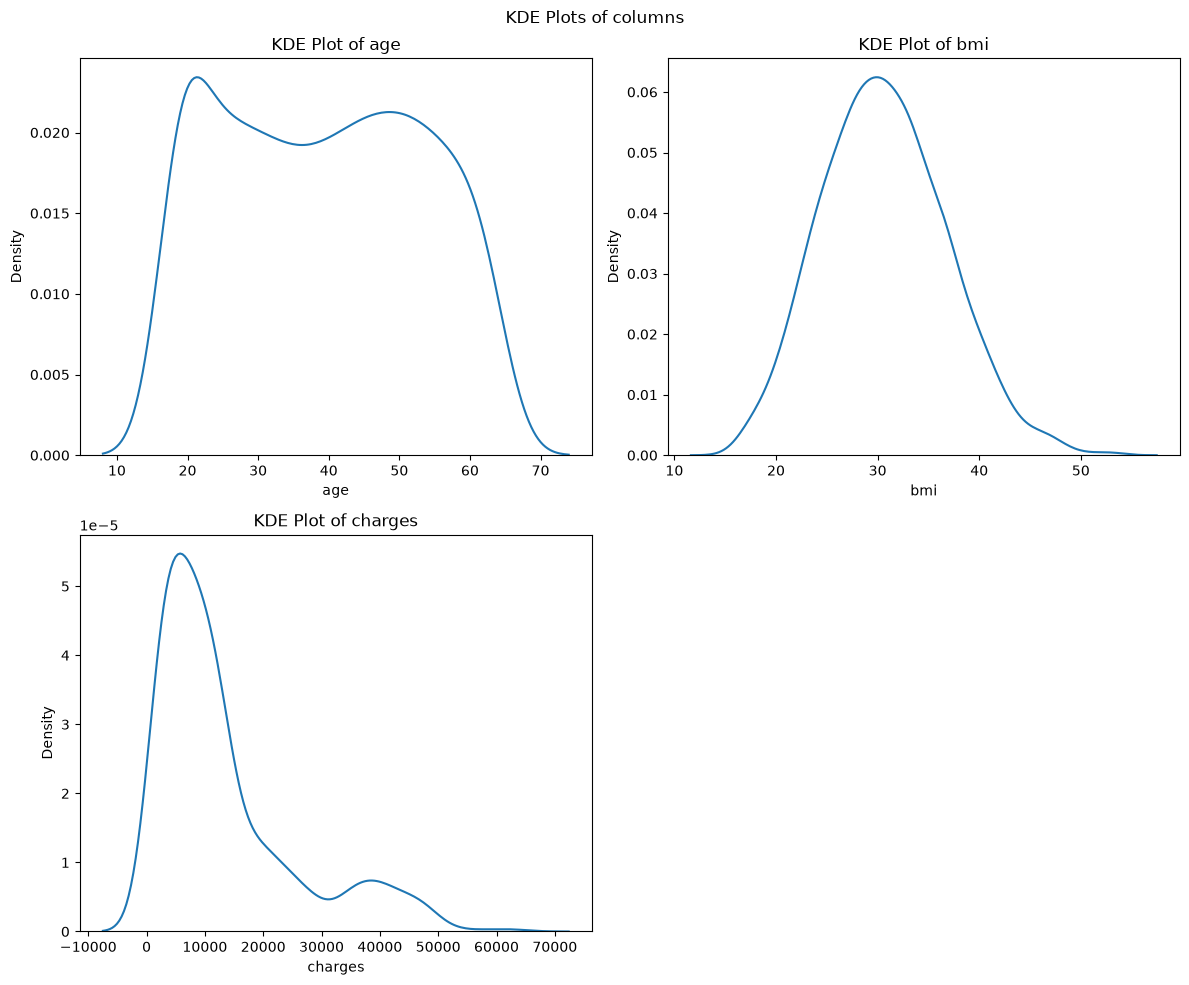

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.suptitle("KDE Plots of columns")
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.kdeplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"KDE Plot of {col}")

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig("images/kdeplots.png", dpi=1200)
plt.show()

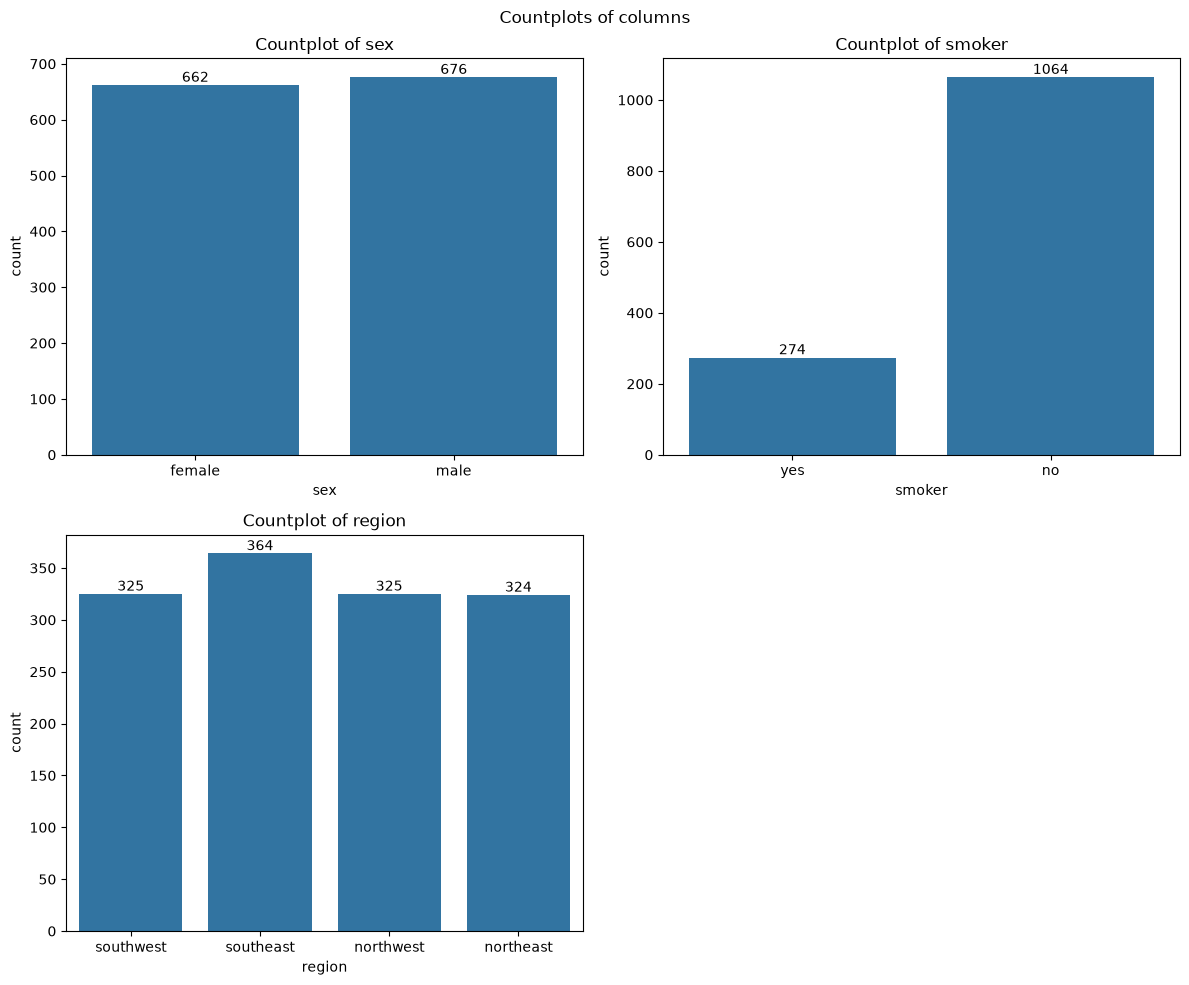

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.suptitle("Countplots of columns")
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    col_to_label = sns.countplot(data=df, x=col, ax=axes[i])
    for container in col_to_label.containers:
        col_to_label.bar_label(container)
    axes[i].set_title(f"Countplot of {col}")

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig("images/countplots.png", dpi=1200)
plt.show()

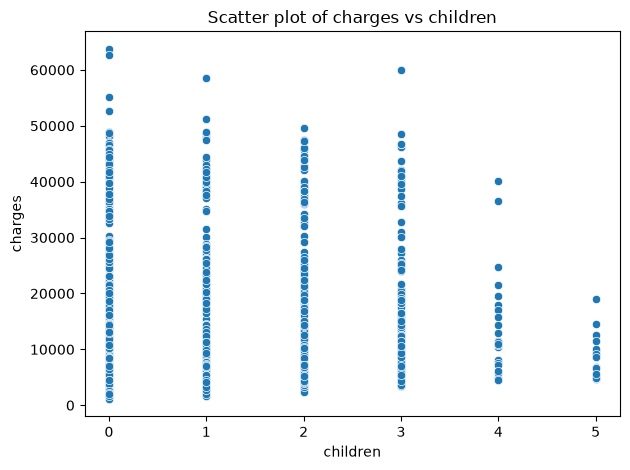

In [9]:
plt.title("Scatter plot of charges vs children")
sns.scatterplot(x=df["children"], y=df["charges"])
plt.tight_layout()
plt.savefig("images/scatterplots_of_charges_vs_children.png", dpi=1200)
plt.show()

In [10]:
for col in categorical_cols:
    print(df[col].value_counts())
    print("\n")

sex
male      676
female    662
Name: count, dtype: int64


smoker
no     1064
yes     274
Name: count, dtype: int64


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64




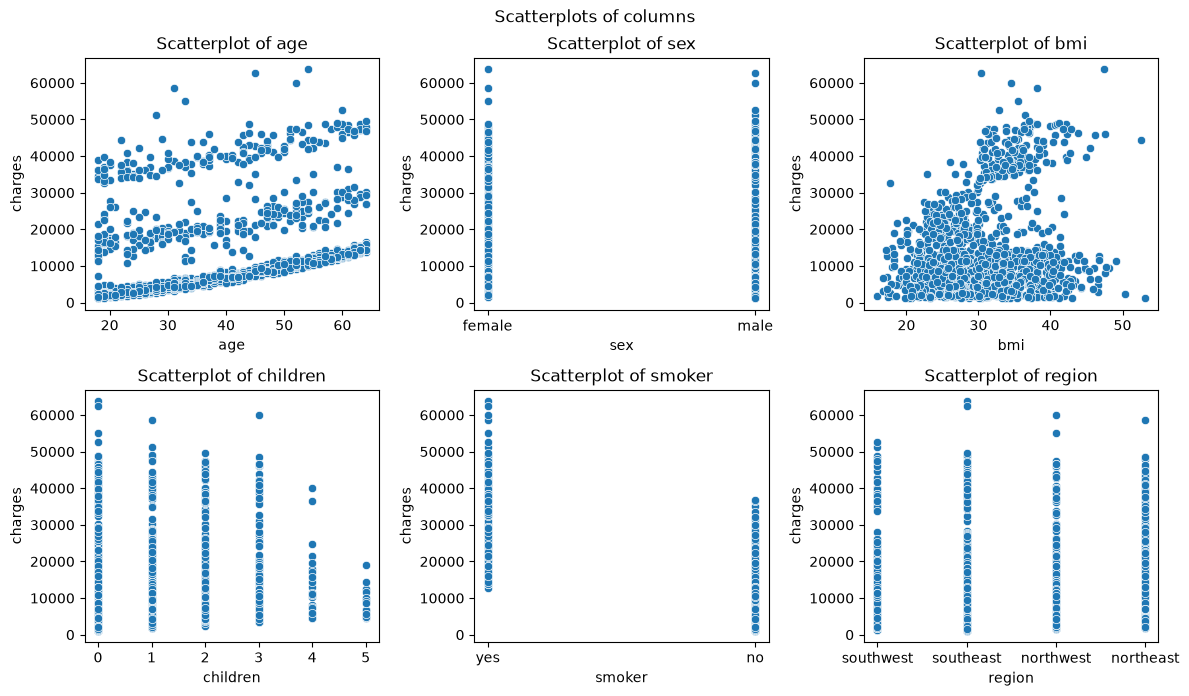

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
plt.suptitle("Scatterplots of columns")
axes = axes.flatten()
for i, col in enumerate(df.columns):
    sns.scatterplot(data=df, x=col, y="charges", ax=axes[i])
    axes[i].set_title(f"Scatterplot of {col}")

axes[-1].set_visible(False)
axes[-2].set_visible(False)
axes[-3].set_visible(False)
plt.tight_layout()
plt.savefig("images/scatterplots.png", dpi=1200)
plt.show()

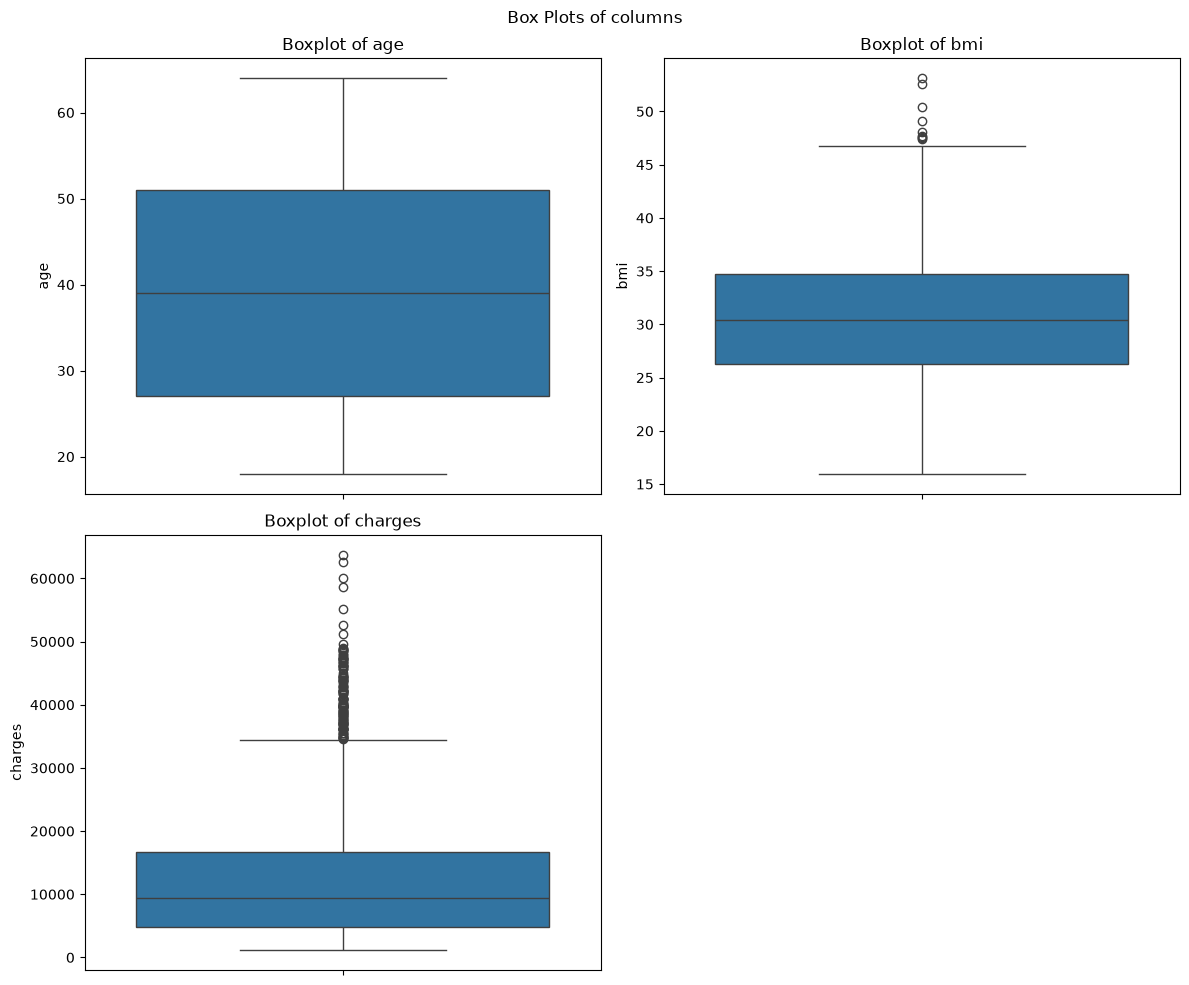

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.suptitle("Box Plots of columns")
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig("images/boxplots.png", dpi=1200)
plt.show()

In [13]:
# Outlier in Charges analysis
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
higher_fence = Q3 + 1.5 * IQR
df.loc[(df["charges"] < lower_fence) | (df["charges"] > higher_fence)]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


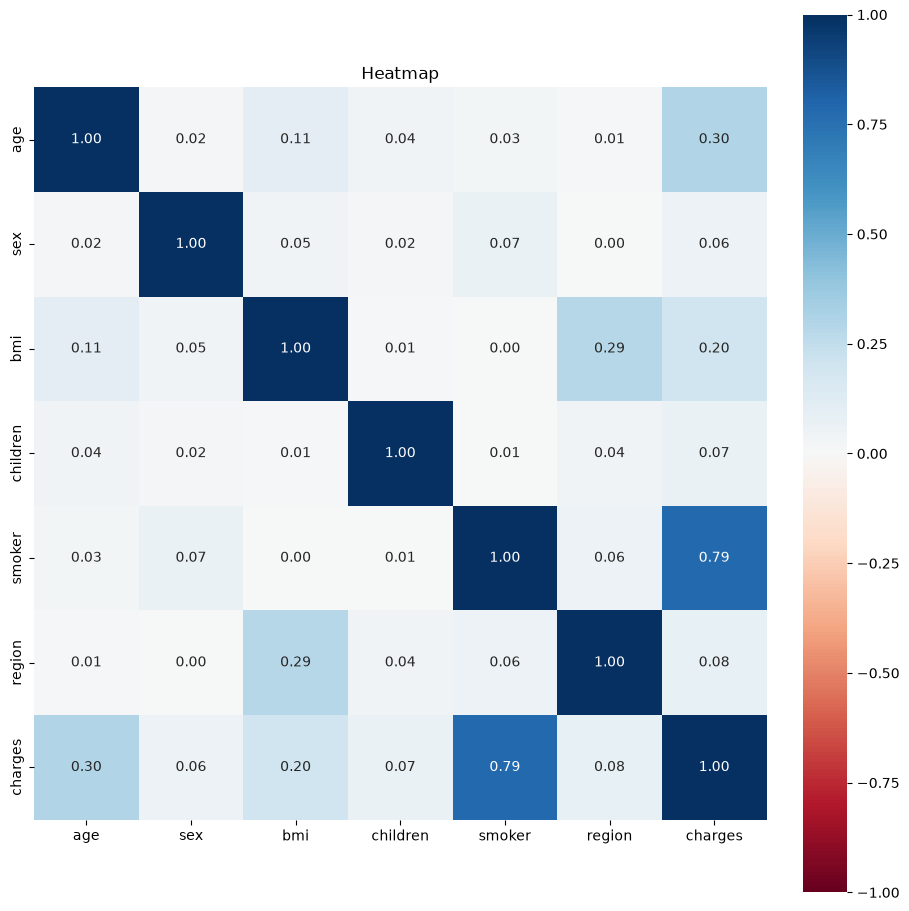

In [14]:
fig, ax = plt.subplots(figsize=(9, 9), layout="constrained")
associations(df, ax=ax, cmap="RdBu", title="Heatmap", filename="images/heatmap.png")
plt.show()

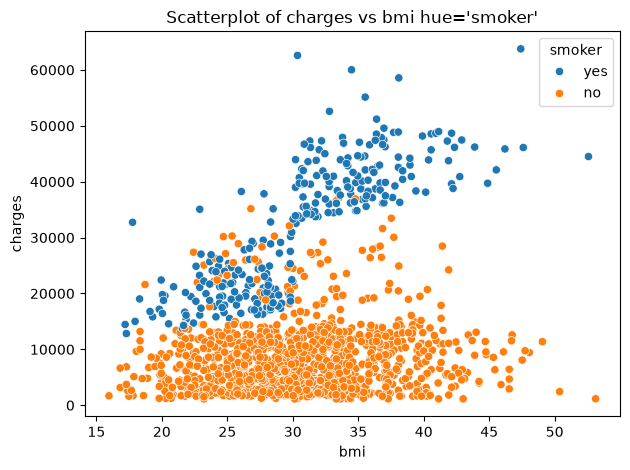

In [15]:
plt.title("Scatterplot of charges vs bmi hue='smoker'")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.tight_layout()
plt.savefig("images/scatterplot_bmi_charges_smoker.png", dpi=1200)

In [16]:
df_vif = df.copy()
df_vif["sex"] = (df_vif["sex"] == "male").astype(int)
df_vif["smoker"] = (df_vif["smoker"] == "yes").astype(int)
df_vif["region"] = df_vif["region"].astype("category").cat.codes
features = ["age", "bmi", "children", "sex", "smoker", "region"]
X_vif = df_vif[features]
X_vif_const = sm.add_constant(X_vif)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i + 1) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False)
print(vif_data)

    Feature       VIF
1       bmi  1.040608
5    region  1.025966
0       age  1.015394
3       sex  1.008889
4    smoker  1.006466
2  children  1.002482


## EDA Summary

### Dataset
Dataset has 1338 records.

### Key Findings

**Smoking is the dominant predictor**

**Three natural subpopulations exist in the data in the charges column.**

**BMI matters only in combination with smoking**
BMI alone has weak correlation with charges. But among smokers, higher 
BMI compounds costs significantly. This motivated two engineered features:
- smoker_bmi: smoker × BMI
- smoker_obese: smoker AND BMI ≥ 30

**Age has moderate positive correlation**
Charges increase with age across all subgroups but the effect is weaker 
than smoking status.

**Multicollinearity Check (VIF)**
All features show VIF values near 1, indicating no meaningful multicollinearity among the raw predictors. This supports using linear models without concern for redundant/correlated features at the input level.

### Modelling Implications
- Smoking status and its interactions must be captured for any model to perform well
- MAE is the preferred evaluation metric due to outliers in the charges distribution